**Importiere die notwendigen Packages**

In [35]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns



Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [36]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

Importiere einen Datensatz von der **DWH_INT** Dropzone.

- Beachte dabei die Notation des Pfades...
- Definiere mal aktuell noch keine weiteren Parameter beim Import

**Dataset auf INTEG Datenkatalog**: https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_zweitevornamen_baby_od3702

In [37]:
# Filepath
fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/DWH/bev_zweitevornamen_baby_OD3702/BEV370OD3702.csv"
#Auf INTEG
#fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_zweitevornamen_baby_OD3702/BEV370OD3702.csv"


# Read the data
data2betested = pd.read_csv(
    fp, 
    sep=',',
   #usecols=[0,1,2,3,4,6],
   #names=['stationid','year','month','avgtemp','latitude','longitude','elevation','station','countryid','country'],
   #skiprows=1,
   # parse_dates=[0],
    parse_dates=True,
    #date_parser=lambda x: pd.to_datetime(x, format="%Y"), 
    #index_col="date_time",
    low_memory=False    
    )

In der Folge ein paar erste Tests:

In [38]:
type(data2betested)

pandas.core.frame.DataFrame

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [39]:
data2betested.head(3)

,StichtagDatJahr,Vorname2,SexLang,AnzGebuWir
0,1993,Aimée,weiblich,1
1,1993,Alessandra,weiblich,1
2,1993,Alexandra,weiblich,16


In [40]:
data2betested.dtypes

StichtagDatJahr     int64
Vorname2           object
SexLang            object
AnzGebuWir          int64
dtype: object

In [41]:
data2betested.shape

(6258, 4)

Beschreibe einzelne Attribute

In [42]:
data2betested.describe()

,StichtagDatJahr,AnzGebuWir
count,6258,6258
mean,2008,4
std,9,4
min,1993,1
25%,2001,2
50%,2008,3
75%,2015,5
max,2022,51


Wie viele Nullwerte gibt es im Datensatz?

In [43]:
data2betested.isnull().sum()

StichtagDatJahr    0
Vorname2           0
SexLang            0
AnzGebuWir         0
dtype: int64

Wandle die Spalte Jahr von Int zu **Datetime** um. Dies wird in den meisten Grafiken so benötigt.

In [44]:
#data2betested['Jahrgang']=pd.to_datetime(data2betested['Jahrgang'], format='%Y')

#TO DO --> setze das Datum auf den 31.12. der Jahres.
#test=data2betested[['StichtagDatJahr']].date().replace(month=12, day=31)

#data2betested

Bereite die Daten für die Grafik unten vor

In [45]:
grp_jahr = data2betested.groupby("StichtagDatJahr")

len(grp_jahr)
grp_jahr.head()



,StichtagDatJahr,Vorname2,SexLang,AnzGebuWir
0,1993,Aimée,weiblich,1
1,1993,Alessandra,weiblich,1
2,1993,Alexandra,weiblich,16
3,1993,Alice,weiblich,3
4,1993,Andrea,weiblich,12
...,...,...,...,...
3137,2022,Aimée,weiblich,1
3138,2022,Alexandra,weiblich,5
3139,2022,Alice,weiblich,3
3140,2022,Amélie,weiblich,1


In [46]:
for key, group in grp_jahr:
    print(key, len(group))


1993 183
1994 194
1995 188
1996 195
1997 196
1998 199
1999 200
2000 196
2001 205
2002 208
2003 218
2004 215
2005 214
2006 222
2007 213
2008 226
2009 223
2010 221
2011 217
2012 212
2013 212
2014 223
2015 217
2016 216
2017 211
2018 204
2019 210
2020 211
2021 212
2022 197


In [47]:
#myJahr = "2019-01-01"
#aktuellesJahr=Jahre.get_group(myJahr)   
#aktuellesJahr

**Selektionen und Aggregationen**

Check this [Doku](https://www.shanelynn.ie/summarising-aggregation-and-grouping-data-in-python-pandas/)

In [48]:
med_gebjahr_sex = data2betested.groupby(['StichtagDatJahr','SexLang'])[['AnzGebuWir']].agg('median')
anz_vn_gebjahr_sex = data2betested.groupby(['StichtagDatJahr', 'SexLang','Vorname2' ])[['AnzGebuWir']].sum()
anz_vn_sex= data2betested.groupby(['SexLang','Vorname2' ])[['AnzGebuWir']].sum()

# produces Pandas Series
    #data2betested.groupby(['StichtagDatJahr', 'KonOGDSort'])['AnzBestWir'].sum()
# Produces Pandas DataFrame
    #data2betested.groupby(['StichtagDatJahr', 'KonOGDSort'])[['AnzBestWir']].sum()



 

Sortiere einen DataFrame

In [49]:
anz_vn_gebjahr_sex.sort_values(by='AnzGebuWir', ascending=False, na_position='first')

AnzGebuWir
StichtagDatJahr SexLang  Vorname2             
2014            weiblich Sophie             51
                         Marie              50
2017            weiblich Maria              49
2015            männlich Alexander          43
2001            weiblich Maria              40
...                                        ...
2011            weiblich Rahel               1
2001            männlich Caspar              1
1995            weiblich Aurora              1
2001            männlich Carl                1
2019            männlich Nicola              1

[6258 rows x 1 columns]

Sortiere eine «Series»

In [50]:
# Diese Aggregation führt zu einem DataFrame. Dieser muss wie vorher gezeigt sortiert werden.
# anz_vn_sex= data2betested.groupby(['SexLang','Vorname' ])[['AnzGebuWir']].sum()

#Folgende Aggregation führt zu einer Series, die anders als ein DF sortiert wird:
anz_vn_sex= data2betested.groupby(['SexLang','Vorname2' ])['AnzGebuWir'].sum()

anz_vn_sex.sort_values(ascending=False, inplace=True, na_position='first')
anz_vn_sex


SexLang   Vorname2 
weiblich  Maria        899
männlich  Alexander    641
weiblich  Sophie       620
          Marie        618
          Sophia       542
                      ... 
          Mirjam        25
          Dominique     22
          Catarina      21
          Sabrina       19
          Tiffany        9
Name: AnzGebuWir, Length: 246, dtype: int64

**Einfache Visualisierungen zur Plausi**

Exploriere die Daten mit Pivottable.JS

In [51]:
#from pivottablejs import pivot_ui

#pivot_ui(data2betested)

**Liniendiagramm Mit Altair**

[Link zur Altair-Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

Füge eine Variablen hinzu, welche den ersten, den zweiten und die ersten beiden Buchstaben des Namens angeben.

In [52]:
data2betested["FirstLetter"]= data2betested["Vorname2"].astype(str).str[0]
data2betested["SecondLetter"]= data2betested["Vorname2"].astype(str).str[1]
data2betested["FirstTwoLetters"]= data2betested["Vorname2"].str.slice(stop=2)
data2betested.sort_values(by='AnzGebuWir', ascending=False, inplace=True, na_position='first')
#.str[0]
#data2betested["StartLetter"]= data2betested["Vorname"].str.extract(r"(\d{2})")
print(data2betested)

      StichtagDatJahr   Vorname2   SexLang  AnzGebuWir FirstLetter SecondLetter FirstTwoLetters
2368             2014     Sophie  weiblich          51           S            o              So
2340             2014      Marie  weiblich          50           M            a              Ma
2670             2017      Maria  weiblich          49           M            a              Ma
5448             2015  Alexander  männlich          43           A            l              Al
1209             2004      Maria  weiblich          40           M            a              Ma
...               ...        ...       ...         ...         ...          ...             ...
2401             2015   Cristina  weiblich           1           C            r              Cr
2402             2015    Daniela  weiblich           1           D            a              Da
4951             2010  Francesco  männlich           1           F            r              Fr
4950             2010    Florian  männli

In [53]:
mySelection = data2betested[(data2betested.StichtagDatJahr>2011) & (data2betested.StichtagDatJahr<2014) & (data2betested.SexLang=='weiblich')]
agg_mySelection= mySelection.groupby(['Vorname2', 'SexLang' ])[['AnzGebuWir']].sum()
agg_mySelection.sort_values(by='AnzGebuWir', ascending=False, inplace=True)
agg_mySelection.head()
#mySelection.head()
#agg_mySelection.dtypes


,,AnzGebuWir
Vorname2,SexLang,
Sophie,weiblich,76
Maria,weiblich,71
Marie,weiblich,61
Sophia,weiblich,51
Anna,weiblich,35


In [54]:
mySelection


,StichtagDatJahr,Vorname2,SexLang,AnzGebuWir,FirstLetter,SecondLetter,FirstTwoLetters
2139,2012,Sophie,weiblich,38,S,o,So
2253,2013,Sophie,weiblich,38,S,o,So
2224,2013,Maria,weiblich,38,M,a,Ma
2116,2012,Maria,weiblich,33,M,a,Ma
2117,2012,Marie,weiblich,32,M,a,Ma
...,...,...,...,...,...,...,...
2203,2013,Laura,weiblich,1,L,a,La
2210,2013,Linda,weiblich,1,L,i,Li
2226,2013,Marina,weiblich,1,M,a,Ma
2229,2013,May,weiblich,1,M,a,Ma


**Erster Test mit Altair-Liniengrafik**

[Link](https://altair-viz.github.io/gallery/multiline_highlight.html)

In [55]:
myGraphic=data2betested[ (data2betested.StichtagDatJahr>2018) & (data2betested.FirstTwoLetters=="La") | (data2betested.FirstTwoLetters=="Lo") & (data2betested.SexLang=="weiblich")]
# --> Weshalb wir die Bedingung auf die Jahre nicht übernommen? 
# --> so würde es in einem 2. Schritt gehen. 
# myGraphic=myGraphicPart[ (myGraphicPart.StichtagDatJahr>2012)]



In [56]:
# df_statzonen = df_statzonen[(df_statzonen.knr>0) & (df_statzonen.qname!="Hirslanden")]
#aktuellesJahr[[aktuellesJahr.KreisSort =7]])


highlight = alt.selection(type='single', on='mouseover',
                          fields=['symbol'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myGraphic).encode(
    x='StichtagDatJahr:N',
    y='AnzGebuWir',
    color='Vorname2'
)

points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=400
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(1.5), alt.value(4))
).interactive()

points + lines

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

In [57]:
alt.Chart(myGraphic).mark_circle(size=60).encode(
    x='Vorname2',
    y='AnzGebuWir',
    color='StichtagDatJahr',
    tooltip=['StichtagDatJahr', 'Vorname2', 'FirstTwoLetters','AnzGebuWir']
).interactive() # this makes the axes interactive: now you can zoom & pan



c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list

alt.Chart(...)

In [58]:
myGraphic



,StichtagDatJahr,Vorname2,SexLang,AnzGebuWir,FirstLetter,SecondLetter,FirstTwoLetters
3090,2021,Lou,weiblich,21,L,o,Lo
2331,2014,Louise,weiblich,19,L,o,Lo
2214,2013,Lou,weiblich,18,L,o,Lo
2982,2020,Louise,weiblich,18,L,o,Lo
2445,2015,Louise,weiblich,16,L,o,Lo
...,...,...,...,...,...,...,...
3080,2021,Laura,weiblich,1,L,a,La
1993,2011,Lorena,weiblich,1,L,o,Lo
2862,2019,Laura,weiblich,1,L,a,La
2872,2019,Lorena,weiblich,1,L,o,Lo


In [59]:
#Siehe dazu Anleitung unter: https://altair-viz.github.io/gallery/scatter_matrix.html
#Daten zu den Bsp. unter:https://altair-viz.github.io/gallery/index.html.

alt.Chart(myGraphic).mark_circle().encode(
    alt.X(alt.repeat("column"), type='ordinal'), #es gibt folgende Typen (quantitative, ordinal, nominal, temporal)
    alt.Y(alt.repeat("row"), type='quantitative'),
    color='Vorname2'
).properties(
    width=150,
    height=150
).repeat(
    column=['Vorname2', 'FirstLetter', 'FirstTwoLetters'],
    row=['StichtagDatJahr', 'AnzGebuWir']
).interactive()

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list

alt.RepeatChart(...)

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


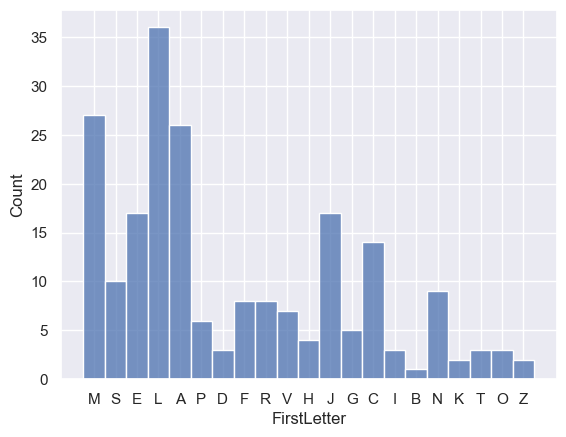

In [60]:
import seaborn as sns
sns.set(style="darkgrid")
sns.histplot(data=data2betested[(data2betested.StichtagDatJahr==2020)] , x="FirstLetter") #, y="SexLang")
plt.show();

Test: Choroplethenkarte

**Test: Choroplethenkarte**
Importiere die Geodaten als GeoJSON

In [61]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Filepath statzonen
input_statzonen = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/stzh.adm_statzonen_map.json"
df_statzonen = gpd.read_file(input_statzonen)
df_statzonen.head(2)


,objectid,objid,stznr,stzname,qnr,qname,knr,kname,geometry
0,1,154,7303,Hegibach,73,Hirslanden,7,Kreis 7,"POLYGON ((8.55670 47.36407, 8.55670 47.36406, ..."
1,2,89,7302,Klus,73,Hirslanden,7,Kreis 7,"POLYGON ((8.57281 47.35806, 8.57274 47.35804, ..."


Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

#Link https://automating-gis-processes.github.io/site/notebooks/L5/interactive-map-folium.html

# Create a Map instance
m = folium.Map(location=[60.25, 24.8], tiles = 'cartodbpositron', zoom_start=10, control_scale=True)

# Plot a choropleth map
# Notice: 'geoid' column that we created earlier needs to be assigned always as the first column
folium.Choropleth(
    geo_data=data,
    name='Population in 2018',
    data=data,
    columns=['geoid', 'pop18'],
    key_on='feature.id',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    line_color='white',
    line_weight=0,
    highlight=False,
    smooth_factor=1.0,
    #threshold_scale=[100, 250, 500, 1000, 2000],
    legend_name= 'Population in Helsinki').add_to(m)

#Show map
m

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html